In [9]:
import pandas as pd
import xarray as xr
from sea_breeze.load_model_data import load_aus2200_variable, interp_model_level_to_z, load_aus2200_static, aus2200_hybrid_height_calc, load_barra_static
from sea_breeze.sea_breeze_funcs import rotate_wind
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from dask.distributed import Client
from metpy.interpolate import cross_section
import metpy.calc as mpcalc
import metpy.units as units
import numpy as np

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46319,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34905,Total threads: 2
Dashboard: /proxy/39543/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:37511,


In [3]:
#Load sea breeze day dataset
region="illawara"
sb_day = pd.read_csv("/g/data/ng72/ab4502/sea_breeze_detection/aus2200_smooth_s4/sb_days/"+region+".csv")
sb_dates = pd.to_datetime(sb_day[sb_day.sb==1]["time"].values)
nonsb_dates = pd.to_datetime(sb_day[sb_day.sb==0]["time"].values)

In [4]:
sb_dates

DatetimeIndex(['2013-01-01', '2013-01-04', '2013-01-05', '2013-01-06',
               '2013-01-08', '2013-01-09', '2013-01-11', '2013-01-12',
               '2013-01-16', '2013-01-17',
               ...
               '2018-02-14', '2018-02-15', '2018-02-16', '2018-02-17',
               '2018-02-18', '2018-02-23', '2018-02-24', '2018-02-25',
               '2018-02-26', '2018-02-28'],
              dtype='datetime64[ns]', length=105, freq=None)

In [16]:
file_list = [
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_201301-201301.nc",
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_201302-201302.nc",
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_201601-201601.nc",
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_201602-201602.nc",
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_201801-201801.nc",
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_201802-201802.nc"
]

lat_slice = slice(-36,-33)
lon_slice = slice(149,152)

barra_ts = (xr.open_mfdataset(
    file_list,chunks={"time":-1,"lat":-1,"lon":-1}).sel(lat=lat_slice,lon=lon_slice) - 273.15).persist()

In [17]:
#orog, lsm = load_barra_static("AUST-04",lon_slice,lat_slice)

rez_shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=lat_slice,lon=lon_slice)

In [29]:
ocean = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/sftlf/latest/sftlf_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc").\
sel(lat=lat_slice,lon=lon_slice).sftlf == 0

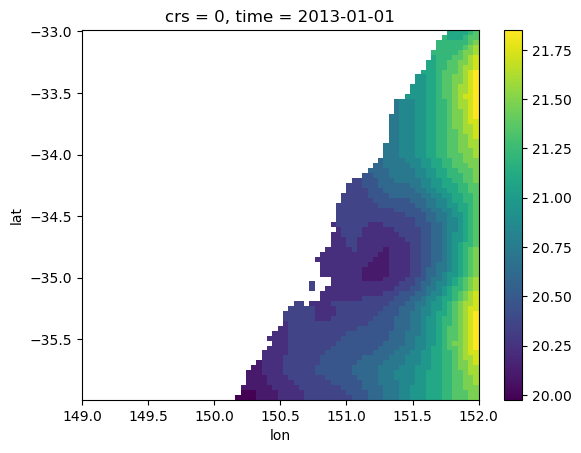

In [30]:
xr.where(ocean,barra_ts.ts.isel(time=0),np.nan).plot()

In [105]:
#transect setting (length in degrees is 2*D)
D=0.5

#Max height for transect
hmax=4500

#The spacing in degrees of the transect central points
delta_transect = np.arange(-0.5,0.55,0.05)

In [5]:
shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes_aus2200.nc")

In [6]:
xx,yy = np.meshgrid(shapes.lon,shapes.lat)


#shapes[region].plot()
region_lon = xr.where(shapes[region+"_landsea"]==1, xx, np.nan)
region_lat = xr.where(shapes[region+"_landsea"]==1, yy, np.nan)

In [7]:
lon_slice = slice(region_lon.min().values - D/2,region_lon.max().values + D/2)
lat_slice = slice(region_lat.min().values - D/2,region_lat.max().values + D/2)

In [8]:
#For day = d
d=-1
sb_dates[d]

Timestamp('2018-02-28 00:00:00')

In [9]:
if (sb_dates[d].year==2013):
    exp_id="mjo-neutral2013"
elif (sb_dates[d].year==2016):
    exp_id="mjo-elnino2016"
elif (sb_dates[d].year==2018):
    exp_id="mjo-lanina2018"    

In [10]:
#Load the AUS2200 data for a certain domain and day
ua = load_aus2200_variable(
    "ua",
    sb_dates[d],
    sb_dates[d].replace(hour=23),
    exp_id,
    lon_slice,
    lat_slice,
    "1hr",
    hgt_slice=slice(0,hmax),
    chunks={},
    interp_hgts=False,
    staggered="lon")
va = load_aus2200_variable(
    "va",
    sb_dates[d],
    sb_dates[d].replace(hour=23),
    exp_id,
    lon_slice,
    lat_slice,
    "1hr",
    hgt_slice=slice(0,hmax),
    chunks={},
    interp_hgts=False,
    staggered="lat")
theta = load_aus2200_variable(
    "theta",
    sb_dates[d],
    sb_dates[d].replace(hour=23),
    exp_id,
    lon_slice,
    lat_slice,
    "1hr",
    hgt_slice=slice(0,hmax),
    chunks={},
    interp_hgts=False) 


Exception ignored in: <function CachingFileManager.__del__ at 0x14b9b3f70cc0>
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [11]:
#Interpolate to height above sea level, mask data below topography
orog, lsm = load_aus2200_static("mjo-elnino2016",lon_slice,lat_slice)
Z_agl_rho = xr.open_zarr("/g/data/ng72/ab4502/sea_breeze_detection/aus2200_z_agl_rho.zarr/",
                     chunks={}).Z_agl.sel(lev=ua.lev,lat=ua.lat,lon=ua.lon)
Z_agl_theta = xr.open_zarr("/g/data/ng72/ab4502/sea_breeze_detection/aus2200_z_agl_theta.zarr/",
                     chunks={}).Z_agl.sel(lev=theta.lev,lat=theta.lat,lon=theta.lon)

ua = interp_model_level_to_z(
    Z_agl_rho-orog,
    ua.chunk({"lev":-1}),
    "lev",
    ua.lev.values,
    model="AUS2200"
    )        
ua = xr.where(((Z_agl_rho.rename({"lev":"height"})-orog)>0),ua,np.nan)

va = interp_model_level_to_z(
    Z_agl_rho-orog,
    va.chunk({"lev":-1}),
    "lev",
    va.lev.values,
    model="AUS2200"
    )        
va = xr.where((Z_agl_rho.rename({"lev":"height"})-orog>0),va,np.nan)

theta = interp_model_level_to_z(
    Z_agl_theta-orog,
    theta.chunk({"lev":-1}),
    "lev",
    theta.lev.values,
    model="AUS2200"
    )        
theta = xr.where((Z_agl_theta.rename({"lev":"height"})-orog>0),theta,np.nan)

zmla = load_aus2200_variable(
    "zmla",
    sb_dates[d],
    sb_dates[d].replace(hour=23),
    "mjo-lanina2018",
    lon_slice,
    lat_slice,
    "1hr",
    chunks={},
    interp_hgts=False,
    staggered="time") + orog

ua = ua.interp({"height":theta.height})
va = va.interp({"height":theta.height})

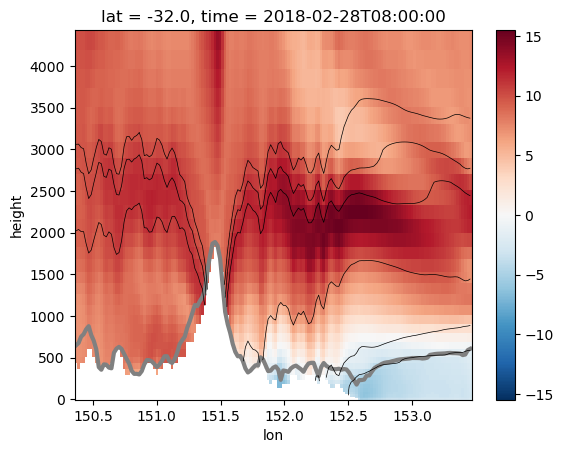

In [12]:
#Test for a single time

ua.isel(time=8).sel(lat=-32,method="nearest").plot(y="height")
zmla.isel(time=8).sel(lat=-32,method="nearest").plot(color="grey",lw=3)
theta.isel(time=8).sel(lat=-32,method="nearest").plot.contour(y="height",levels=np.arange(290,320,4),colors="k",linewidths=0.5)

In [13]:
#Plot surface winds

# ax=plt.axes(projection=ccrs.PlateCarree())
# xr.Dataset({"u":ua,"v":va}).isel(height=0,time=9).coarsen({"lon":10,"lat":10},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")
# ax.coastlines()

In [81]:
#Set up transect

#First, load angle dataset for AUS2200

angle_ds = xr.open_dataset(
        "/g/data/ng72/ab4502/coastline_data/aus2200.nc"
    ).sel(lat=lat_slice,lon=lon_slice)
# angle_ds = xr.open_dataset(
#         "/g/data/ng72/ab4502/coastline_data/era5.nc"
#     ).interp(lat=ua.lat,lon=ua.lon)

#Find nearest coastline point to centre of landsea region
x = region_lon.mean().values
y = region_lat.mean().values
xx,yy = np.meshgrid(angle_ds.lon,angle_ds.lat)
ind = np.nanargmin(np.where(angle_ds.coast,np.sqrt(((xx-x)**2 + (yy-y)**2)),np.nan))
x_coast = xx.flatten()[ind]
y_coast = yy.flatten()[ind]


In [82]:
# import scipy

# x = xr.where(
#     shapes.sel(lat=lat_slice,lon=lon_slice)[region+"_landsea"],
#     angle_ds.angle_interp,
#     np.nan)
# avg_angle = scipy.stats.circmean(x,nan_policy="omit",high=365)


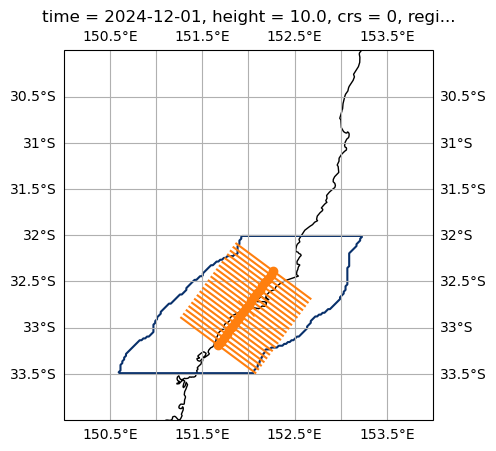

In [106]:
#First method of getting transects:

# - Start with coastal point in centre of land sea region
# - Using the central coastline angle, advance up and down a line drawn through that point at that angle
# - Stop each delta_transect distance, and draw a transect perpendicular to that line



#angle = avg_angle
#angle = angle_ds.angle_interp.rolling({"lat":40,"lon":40},center=True).mean().sel(lat=y_coast,lon=x_coast).values
angle = angle_ds.angle_interp.sel(lat=y_coast,lon=x_coast).values

center_points = []
for delta in delta_transect:
    center_points.append([y_coast + delta * np.sin(np.deg2rad(angle)), x_coast + delta * np.cos(np.deg2rad(angle))])

angle_rotated = angle-90
if angle_rotated < 0:
    angle_rotated = angle_rotated+360

end_points = []
start_points = []
for c in center_points:
    end_points.append([c[0] + D * np.sin(np.deg2rad(angle_rotated)), c[1] + D * np.cos(np.deg2rad(angle_rotated))])
    start_points.append([c[0] - D * np.sin(np.deg2rad(angle_rotated)), c[1] - D * np.cos(np.deg2rad(angle_rotated))])


#Plot the transects
ax = plt.axes(projection=ccrs.PlateCarree())

shapes.sel(lat=lat_slice,lon=lon_slice)[region+"_landsea"].plot.contour(levels=1,cmap="Blues")
plt.plot(x_coast,y_coast,marker="x",color="tab:orange",ms=12)


ax.gridlines(draw_labels=True)
ax.coastlines()
[plt.plot(c[1],c[0],color="tab:orange",marker="o") for c in center_points];

plt.ylim([-34,-30])
plt.xlim([150,154])

[plt.plot([s[1],e[1]],[s[0],e[0]],color="tab:orange") for s, e in zip(start_points,end_points)];

(150.0, 154.0)

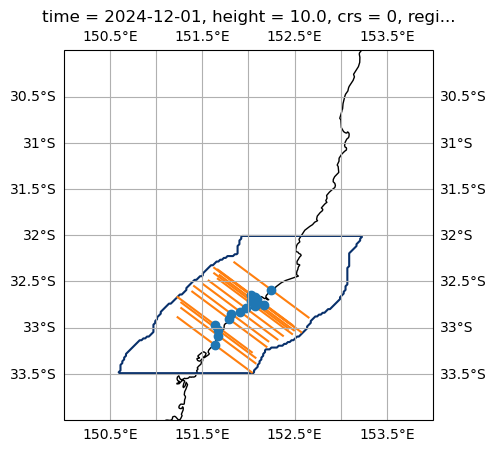

In [107]:
#Second method of getting transect.

# - Again start with central coastal point
# - Find all coastal points within D degrees
# - Take every N coastal points
# - Based on the angle of the central coastal point, draw a transect perpendicular


coast_x_ind, coast_y_ind = np.where(angle_ds.coast)
lon = angle_ds.lon
lat = angle_ds.lat
xx,yy = np.meshgrid(lon,lat)
coast_lon = xx[coast_x_ind,coast_y_ind]
coast_lat = yy[coast_x_ind,coast_y_ind]

dist = np.sqrt((x_coast - coast_lon)**2 + (x_coast - coast_lon)**2)

coast_lon = coast_lon[dist<=D]
coast_lat = coast_lat[dist<=D]

coast_lon = coast_lon[0:-1:10]
coast_lat = coast_lat[0:-1:10]

angle = angle_ds.angle_interp.sel(lat=y_coast,lon=x_coast).values

center_points = []
for lon,lat in zip(coast_lon,coast_lat):
    center_points.append([lat, lon])

angle_rotated = angle-90
if angle_rotated < 0:
    angle_rotated = angle_rotated+360

end_points = []
start_points = []
for c in center_points:
    end_points.append([c[0] + D * np.sin(np.deg2rad(angle_rotated)), c[1] + D * np.cos(np.deg2rad(angle_rotated))])
    start_points.append([c[0] - D * np.sin(np.deg2rad(angle_rotated)), c[1] - D * np.cos(np.deg2rad(angle_rotated))])


#Plot the transects
ax = plt.axes(projection=ccrs.PlateCarree())

shapes.sel(lat=lat_slice,lon=lon_slice)[region+"_landsea"].plot.contour(levels=1,cmap="Blues")
#plt.plot(x_coast,y_coast,marker="x",color="tab:orange",ms=12)

[plt.plot([s[1],e[1]],[s[0],e[0]],color="tab:orange") for s, e in zip(start_points,end_points)];

plt.plot(coast_lon,coast_lat,marker="o",ls="none")

ax.gridlines(draw_labels=True)
ax.coastlines()
#[plt.plot(c[1],c[0],color="tab:orange",marker="o") for c in center_points];

plt.ylim([-34,-30])
plt.xlim([150,154])





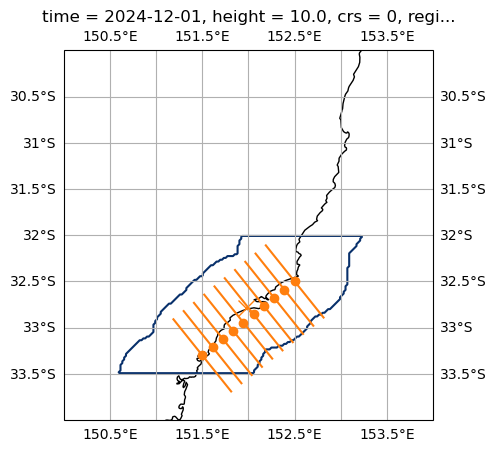

In [112]:
#First method of getting transects:

# - Start with coastal point in centre of land sea region
# - Using the central coastline angle, advance up and down a line drawn through that point at that angle
# - Stop each delta_transect distance, and draw a transect perpendicular to that line



start_coast = [-33.3,151.5]
end_coast = [-32.5,152.5]
angle = np.rad2deg(np.arctan2( (end_coast[0]-start_coast[0]) , (end_coast[1]-start_coast[1]) ))

delta_transect = np.linspace(0,np.sqrt((end_coast[0]-start_coast[0])**2 + (end_coast[1]-start_coast[1])**2),10)

center_points = []
for delta in delta_transect:
    center_points.append([start_coast[0] + delta * np.sin(np.deg2rad(angle)), start_coast[1] + delta * np.cos(np.deg2rad(angle))])

angle_rotated = angle-90
if angle_rotated < 0:
    angle_rotated = angle_rotated+360

end_points = []
start_points = []
for c in center_points:
    end_points.append([c[0] + D * np.sin(np.deg2rad(angle_rotated)), c[1] + D * np.cos(np.deg2rad(angle_rotated))])
    start_points.append([c[0] - D * np.sin(np.deg2rad(angle_rotated)), c[1] - D * np.cos(np.deg2rad(angle_rotated))])


#Plot the transects
ax = plt.axes(projection=ccrs.PlateCarree())

shapes.sel(lat=lat_slice,lon=lon_slice)[region+"_landsea"].plot.contour(levels=1,cmap="Blues")
plt.plot(x_coast,y_coast,marker="x",color="tab:orange",ms=12)


ax.gridlines(draw_labels=True)
ax.coastlines()
[plt.plot(c[1],c[0],color="tab:orange",marker="o") for c in center_points];

plt.ylim([-34,-30])
plt.xlim([150,154])

[plt.plot([s[1],e[1]],[s[0],e[0]],color="tab:orange") for s, e in zip(start_points,end_points)];

In [86]:
uprime,vprime = rotate_wind(ua,va,angle)

In [87]:
steps = ((2*D) * 100) / 2.2

vprime_trans = []
zmla_trans = []
theta_trans = []

for i in np.arange(len(start_points)):

    vprime_trans.append(cross_section(
        xr.Dataset({"vprime":vprime}).metpy.parse_cf().vprime,
        end_points[i],start_points[i],steps=steps))

    zmla_trans.append(cross_section(
        xr.Dataset({"vprime":zmla}).metpy.parse_cf().vprime,
        end_points[i],start_points[i],steps=steps))

    theta_trans.append(cross_section(
        xr.Dataset({"vprime":theta}).metpy.parse_cf().vprime,
        end_points[i],start_points[i],steps=steps))



vprime_trans = xr.concat(vprime_trans,dim="transect").mean("transect")
zmla_trans = xr.concat(zmla_trans,dim="transect").mean("transect")
theta_trans = xr.concat(theta_trans,dim="transect").mean("transect")

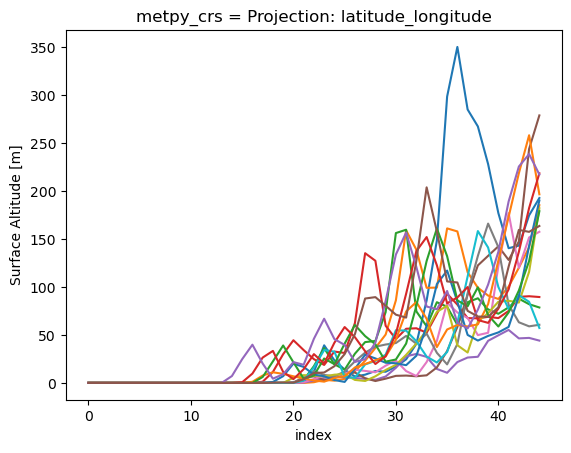

In [88]:
for i in np.arange(len(end_points)):
    cross_section(
        xr.Dataset({"orog":orog}).metpy.parse_cf().orog,
        end_points[i],start_points[i],steps=steps).plot()

Text(0.5, 1.0, '14 AWST')

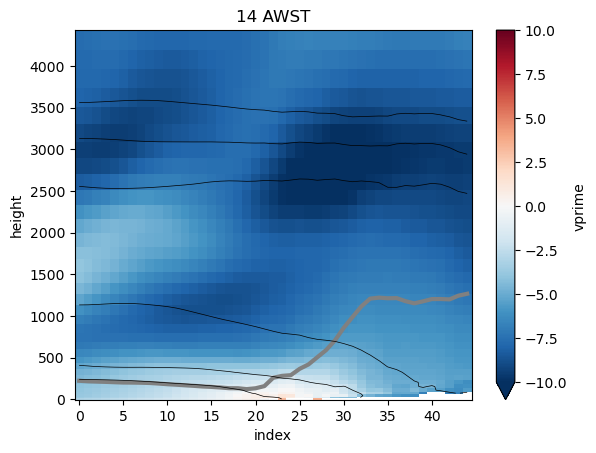

In [92]:
t=6

plt.figure()
vprime_trans.isel(time=t).plot(vmin=-10,vmax=10,cmap="RdBu_r",y="height")
zmla_trans.isel(time=t).plot(color="grey",lw=3)
theta_trans.isel(time=8).plot.contour(y="height",levels=np.arange(290,320,4),colors="k",linewidths=0.5)
plt.title(str(t+8)+" AWST")

In [93]:
#To do:
# - Plot coastline
# - Average along transect
# - Run for all regions/sb days and save (with some info of prevailing wind dir)
# - Save transect infor for labelling xdim.

(0.0, 2000.0)

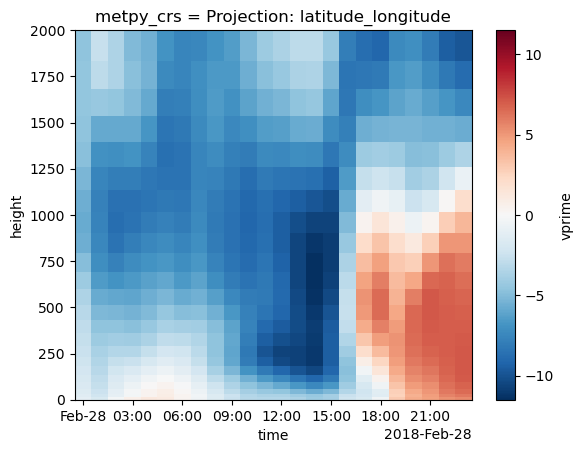

In [94]:
vprime_trans.sel(index=slice(15,25)).mean("index").plot(y="height")
plt.ylim([0,2000])

In [1]:
dict?

Init signature: dict(self, /, *args, **kwargs)
Docstring:     
dict() -> new empty dictionary
dict(mapping) -> new dictionary initialized from a mapping object's
    (key, value) pairs
dict(iterable) -> new dictionary initialized as if via:
    d = {}
    for k, v in iterable:
        d[k] = v
dict(**kwargs) -> new dictionary initialized with the name=value pairs
    in the keyword argument list.  For example:  dict(one=1, two=2)
Type:           type
Subclasses:     OrderedDict, defaultdict, Counter, _EnumDict, _Quoter, Bunch, ObjectDict, StgDict, ConvertingDict, Config, ...